In [3]:
## Imports and prereqs
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import yaml

foldname = 'Day1'
filename = '01062026DataMUODelay.csv'

if "data" not in os.getcwd():
    path = os.path.join(os.path.dirname(os.getcwd()), 'data', foldname)
    os.chdir(path)


C:\Users\Dumitru Andrei\AppData\Local\Temp\ipykernel_2420\4169834381.py:4: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=1`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  head = np.loadtxt(filename, delimiter=',', dtype=str  , max_rows=1)


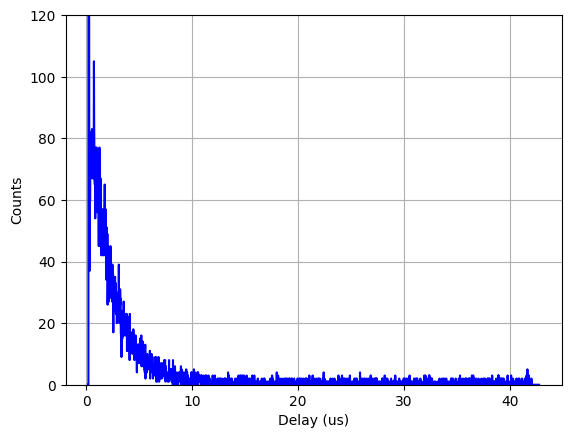

In [ ]:
## Load the data file

data = np.loadtxt(filename, delimiter=',', dtype=float, skiprows=1)
head = np.loadtxt(filename, delimiter=',', dtype=str  , max_rows=1)

dlvals = data[:,0]
dlerrs = data[:,1]
counts = data[:,2]

plt.errorbar(dlvals, counts, color = 'blue', xerr = dlerrs)
plt.ylabel('Counts')
plt.xlabel('Delay (us)')
#plt.ylim((0,120))
plt.grid()
plt.show()

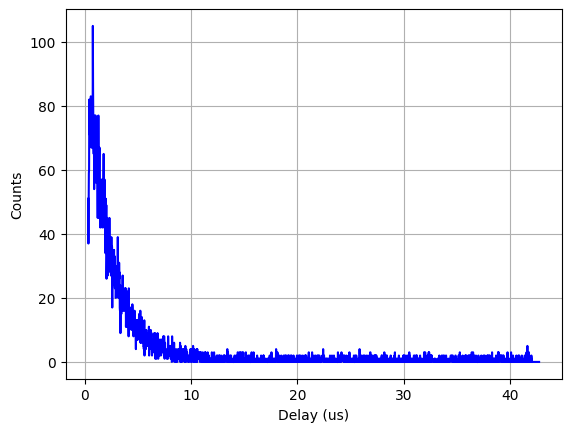

In [50]:
## Filter initial noise peak

justTesting = True # Change to False when you want to permanently change the arrays
filterindex = 0

if justTesting is False:
    dlvals = dlvals[filterindex:]
    dlerrs = dlerrs[filterindex:]
    counts = counts[filterindex:]

plt.errorbar(dlvals[filterindex:], counts[filterindex:], color = 'blue', xerr = dlerrs[filterindex:])
plt.ylabel('Counts')
plt.xlabel('Delay (us)')
#plt.ylim((0,120))
plt.grid()
plt.show()

In [124]:
## Fit the exponential
import odrpack

# Linear fitting def
def fitting_funct(xVal, params: np.ndarray):
    '''Fitting function for the given datapoints'''
    return params[0]*np.exp(-xVal/params[1])

#popt, _ = scipy.optimize.curve_fit(lambda x,a,b,c: fitting_funct(x,[a,b,c]), dlvals, counts, sigma=1)

popt = np.array([100, 2.19])

# Models, 5% error for delays, 1 error for counts
output = odrpack.odr_fit(fitting_funct, dlvals, counts, popt, 
                         weight_x=1/(dlerrs), weight_y=1/(np.sqrt(1+counts)),
                         bounds = [0.8*popt,1.15*popt])

#print(output.beta)
#print(output.cov_beta)

print(output.beta)
print(f'Lower bounds: {0.8*popt}')
print(f'Upper bounds: {1.15*popt}')

for i in range(len(output.beta)):
    print(f"Statistical error on parameter {i}: {round(np.sqrt(output.cov_beta[i][i])/(abs(output.beta[i]))*100, 2)}%")

[92.941119   2.2811342]
Lower bounds: [80.     1.752]
Upper bounds: [115.       2.5185]
Statistical error on parameter 0: 0.69%
Statistical error on parameter 1: 0.67%


Muon lifetime: 2.2811341963357963 +/- 0.015233600684461382


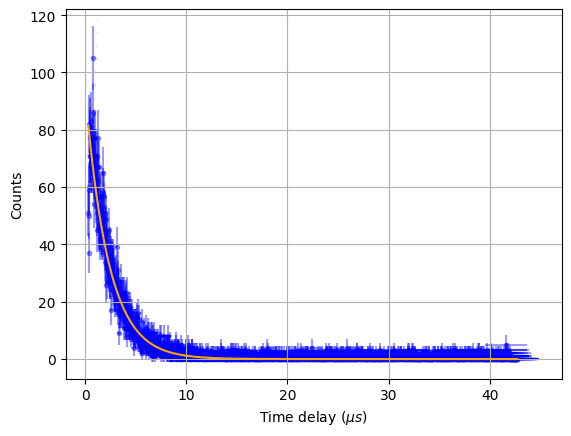

In [128]:
# Plot data and fit

plotRange = np.linspace(min(dlvals), max(dlvals), 1000)

print(rf"Muon lifetime: {output.beta[1]} +/- {np.sqrt(output.cov_beta[1][1])}")

plt.errorbar(dlvals, counts, xerr=0.05*dlvals, yerr = 1+np.sqrt(counts), fmt='.', color = 'blue', alpha = 0.4, zorder=1)
plt.plot(plotRange, fitting_funct(plotRange, [output.beta[0], output.beta[1]]), color = 'orange', alpha = 1)


xrange = np.linspace(plt.xlim()[0],plt.xlim()[1], 1000)
yrange = np.linspace(plt.ylim()[0],plt.ylim()[1], 1000)

X, Y = np.meshgrid(xrange, yrange)

Ymin = (output.beta[0]-output.cov_beta[0][0])*X + output.beta[1] - output.cov_beta[1][1]
Ymax = (output.beta[0]+output.cov_beta[0][0])*X + output.beta[1] + output.cov_beta[1][1]

Z = np.logical_and(np.less(Y, Ymax) , np.less(Ymin, Y))

plt.contourf(X ,Y ,Z ,levels = [0.99, 1.01], cmap = 'Reds', alpha = 0.35)

plt.xlabel(r"Time delay ($\mu s$)")
plt.ylabel("Counts")
plt.grid()
plt.show()